# Regression 3DSC

In [1]:
from __future__ import print_function, division   
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

import optuna
import umap
from sklearn.metrics import silhouette_score

import lightgbm as lgb 
from scipy.stats import randint, poisson
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA

from sklearn.metrics import mean_squared_error, log_loss
from lightgbm import early_stopping
import time

SavePlots = False

import sys
sys.path.insert(1, '/Users/fbnielsen/Library/CloudStorage/OneDrive-UniversityofCopenhagen/Uni OneDrive/4 år/AMAS')

import amasF as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

from iminuit.cost import UnbinnedNLL
from iminuit import Minuit, cost

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 16,
    "axes.grid": True,
    "grid.alpha": 0.2
})

import re

def contains_element(formula, element):
    # Match element symbol not followed by a lowercase letter (avoids e.g. 'Co' matching 'C')
    pattern = r'(?<![A-Z])' + element + r'(?![a-z])'
    return bool(re.search(pattern, str(formula)))

/Users/fbnielsen/miniconda3/envs/tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df_wchem = pd.read_csv('/Users/fbnielsen/Desktop/Initial_class_reg_dimred/3DSC/Dimensionality_reduction/df_wchem_icds.csv')
tc = pd.read_csv('/Users/fbnielsen/Desktop/Initial_class_reg_dimred/3DSC/Dimensionality_reduction/tc_icds.csv')
tc.drop(columns=['Unnamed: 0'], inplace=True)
df_wchem.drop(columns=['Unnamed: 0'], inplace=True)

df_wchem

,lata_2,latb_2,latc_2,cell_volume_2,num_elements_sc,cubic,hexagonal,monoclinic,orthorhombic,tetragonal,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,2.860035,2.860035,2.860035,66.17,2,6,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
1,2.707500,2.707500,4.762700,30.24,2,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.995,0.0
2,4.408800,4.408800,5.946242,196.84,4,0,0,0,0,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
3,4.457601,4.457601,4.457601,250.52,3,6,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
4,4.468208,4.468208,4.468208,252.32,3,6,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75845,3.233200,3.233200,5.146600,46.59,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0
75846,3.232080,3.232080,5.147720,46.57,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0
75847,3.232200,3.232200,5.147500,46.57,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0
75848,3.232000,3.232000,5.147000,46.56,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0


## Initial regression

In [10]:
mask = tc > 0

Xr_train, xr_test, Yr_train, yr_test = train_test_split(df_wchem[mask.values], tc[mask.values], test_size=0.4, random_state=42)
Xr_test, Xr_val, Yr_test, Yr_val = train_test_split(xr_test, yr_test, test_size=0.5, random_state=42)

In [18]:
df_wchem

,lata_2,latb_2,latc_2,cell_volume_2,num_elements_sc,cubic,hexagonal,monoclinic,orthorhombic,tetragonal,...,Ti,Tl,Tm,U,V,W,Y,Yb,Zn,Zr
0,2.860035,2.860035,2.860035,66.17,2,6,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
1,2.707500,2.707500,4.762700,30.24,2,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.995,0.0
2,4.408800,4.408800,5.946242,196.84,4,0,0,0,0,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
3,4.457601,4.457601,4.457601,250.52,3,6,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
4,4.468208,4.468208,4.468208,252.32,3,6,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75845,3.233200,3.233200,5.146600,46.59,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0
75846,3.232080,3.232080,5.147720,46.57,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0
75847,3.232200,3.232200,5.147500,46.57,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0
75848,3.232000,3.232000,5.147000,46.56,1,0,7,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,1.0


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4167
[LightGBM] [Info] Number of data points in the train set: 34668, number of used features: 92
[LightGBM] [Info] Start training from score 3.340098
Training until validation scores don't improve for 20 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.0571082
Regression performance on validation set
RMSE : 6.8118
MAE  : 4.3092
R²   : 0.9564


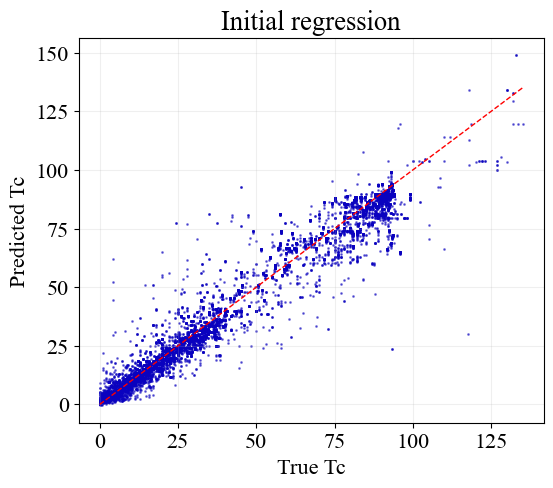

34668 11556 11556 so total number of samples: 57780


In [17]:
lgb_train = lgb.Dataset(Xr_train, np.log1p(Yr_train))
lgb_eval  = lgb.Dataset(Xr_test,  np.log1p(Yr_test), reference=lgb_train)

params = {
    'boosting_type': 'gbdt', 
    'objective': 'regression',  
    'num_leaves': 6,        
    'verbose': 1,           
}

# Train the model:
gbm = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=1000,               # How many rounds for training
                valid_sets=lgb_eval,                # Data to use for validation
                callbacks=[early_stopping(20)])     # Stops if no improvement is seen in N=20 rounds.


y_pred = gbm.predict(Xr_test, num_iteration=gbm.best_iteration)  

# Evaluate initial model:
y_pred_val = np.expm1(gbm.predict(Xr_val, num_iteration=gbm.best_iteration))
mse  = mean_squared_error(Yr_val, y_pred_val)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(Yr_val, y_pred_val)
r2   = r2_score(Yr_val, y_pred_val)

print('Regression performance on validation set')
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.scatter(Yr_val, y_pred_val, s=1, alpha=0.5)
ax.plot([Yr_val.min(), Yr_val.max()], [Yr_val.min(), Yr_val.max()], 'r--', lw=1)
ax.set_xlabel('True Tc')
ax.set_ylabel('Predicted Tc')
ax.set_title(f'Initial LGB  |  R² = {r2:.3f}')
# ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_title('Initial regression')

plt.show()

print(len(Xr_train), len(Xr_test), len(Xr_val), 'so total number of samples:', len(Xr_train) + len(Xr_test) + len(Xr_val))


## Feature importance

In [63]:
import shap

Xr_test_shap = Xr_test.copy()
bool_cols = Xr_test_shap.select_dtypes(include='bool').columns
Xr_test_shap[bool_cols] = Xr_test_shap[bool_cols].astype(int)

explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(Xr_test_shap)

shap_importance = np.abs(shap_values).mean(axis=0)

shap.summary_plot(shap_values, Xr_test_shap,
                  feature_names=Xr_test_shap.columns,
                  plot_type="violin", max_display=25)

Xr_test_shap = Xr_test.select_dtypes(include='number').astype(float)


feature_importance_df = pd.DataFrame({
    'feature': Xr_train.columns, 
    'importance': shap_importance
}).sort_values('importance', ascending=False)

# Extract top 15
top_features = feature_importance_df.head(19)

# Get just the feature names as a list
feat_shap = top_features['feature'].tolist()
print(feat_shap)

plt.figure(figsize=(10,6))
plt.plot(feature_importance_df.head(25)['feature'].tolist(), feature_importance_df.head(25)['importance'], marker='o')
plt.plot(feat_shap, top_features['importance'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.show()

[LightGBM] [Fatal] The number of features in data (110) is not the same as it was in training data (19).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (110) is not the same as it was in training data (19).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
from sklearn.metrics import root_mean_squared_error, r2_score
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), 
    index=Xr_train.columns
)

results = {}
for n_feats in [10, 20, 30, 50, 70, 100, len(shap_values)]:
    top_feats = shap_importance.nlargest(n_feats).index.tolist()
    
    model = lgb.LGBMRegressor(**params)
    model.fit(Xr_train[top_feats], Yr_train,
              eval_set=[(Xr_test[top_feats], Yr_test)],
              eval_metric="rmse",
              callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)])
    
    y_pred = model.predict(Xr_test[top_feats])
    results[n_feats] = {
        'rmse': root_mean_squared_error(Yr_test, y_pred),
        'r2':   r2_score(Yr_test, y_pred)
    }

for n, metrics in results.items():
    print(f"  {n:>4} features — RMSE: {metrics['rmse']:.3f} K   R²: {metrics['r2']:.3f}")

Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 9.24437	valid_0's l2: 85.4584
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 9.06233	valid_0's l2: 82.1258
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 9.05748	valid_0's l2: 82.038
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 9.06355	valid_0's l2: 82.1479
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 9.08253	valid_0's l2: 82.4924
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 9.05198	valid_0's l2: 81.9383
Training until validation sco

## Optimize

In [64]:
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error

def objective_shap(trial):
    Yr_train_log = np.log1p(Yr_train)
    Yr_test_log = np.log1p(Yr_test)

    lr = trial.suggest_float("learning_rate", 1e-4, 0.05, log=True)
    
    # Scale early stopping patience with learning rate
    patience = int(min(max(50, 0.1 / lr), 500))

    params = {
        "objective": "regression",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,
        "n_jobs": -1,
        "learning_rate":     lr,
        "num_leaves":        trial.suggest_int  ("num_leaves",        16,   256),
        "max_depth":         trial.suggest_int  ("max_depth",         3,    12),
        "min_child_samples": trial.suggest_int  ("min_child_samples", 5,    200),
        "subsample":         trial.suggest_float("subsample",         0.5,  1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree",  0.5,  1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",         1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",        1e-8, 10.0, log=True),
    }

    model = lgb.LGBMRegressor(**params, n_estimators=10000)
    model.fit(
        Xr_train[feat_shap],
        Yr_train_log,
        eval_set=[(Xr_test[feat_shap], Yr_test_log)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(patience),
            lgb.log_evaluation(0),
        ],
    )

    y_pred = np.expm1(model.predict(Xr_test[feat_shap]))
    return root_mean_squared_error(Yr_test, y_pred)

study_shap = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2,
    ),
)
study_shap.optimize(
    objective_shap,
    n_trials=500,
    show_progress_bar=True,
)

print("\nBest RMSE:", study_shap.best_value)
print("\nBest Parameters:")
for k, v in study_shap.best_params.items():
    print(f"  {k}: {v}")


[I 2026-05-28 12:40:56,795] A new study created in memory with name: no-name-2ca9319c-861e-4ee8-bbda-c1a28bee674b
  0%|          | 0/500 [00:00<?, ?it/s]

Training until validation scores don't improve for 97 rounds
Did not meet early stopping. Best iteration is:
[10000]	valid_0's rmse: 0.893564	valid_0's l2: 0.798457


Best trial: 0. Best value: 11.5972:   0%|          | 1/500 [01:11<9:55:46, 71.64s/it]

[I 2026-05-28 12:42:08,430] Trial 0 finished with value: 11.59717758735323 and parameters: {'learning_rate': 0.0010253509690168491, 'num_leaves': 245, 'max_depth': 10, 'min_child_samples': 122, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887}. Best is trial 0 with value: 11.59717758735323.
Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 11.5972:   0%|          | 2/500 [01:37<6:09:48, 44.56s/it]

...

Early stopping, best iteration is:
[1129]	valid_0's rmse: 0.856633	valid_0's l2: 0.73382
[I 2026-05-28 14:22:09,955] Trial 497 finished with value: 10.790547914744343 and parameters: {'learning_rate': 0.037972996677947075, 'num_leaves': 215, 'max_depth': 12, 'min_child_samples': 105, 'subsample': 0.8916842141736762, 'colsample_bytree': 0.9540538280018571, 'reg_alpha': 9.962820713587822e-05, 'reg_lambda': 0.2193958954198757}. Best is trial 376 with value: 10.643541469132943.
Training until validation scores don't improve for 50 rounds


Best trial: 376. Best value: 10.6435: 100%|█████████▉| 499/500 [1:41:18<00:06,  6.79s/it]

Early stopping, best iteration is:
[976]	valid_0's rmse: 0.853046	valid_0's l2: 0.727688
[I 2026-05-28 14:22:15,451] Trial 498 finished with value: 10.714139587922697 and parameters: {'learning_rate': 0.041062984441905946, 'num_leaves': 206, 'max_depth': 12, 'min_child_samples': 91, 'subsample': 0.8721223096846346, 'colsample_bytree': 0.9712061962364024, 'reg_alpha': 5.7850626389036774e-05, 'reg_lambda': 0.05251280179375795}. Best is trial 376 with value: 10.643541469132943.
Training until validation scores don't improve for 50 rounds


Best trial: 376. Best value: 10.6435: 100%|██████████| 500/500 [1:41:24<00:00, 12.17s/it]

Early stopping, best iteration is:
[1103]	valid_0's rmse: 0.856332	valid_0's l2: 0.733305
[I 2026-05-28 14:22:21,458] Trial 499 finished with value: 10.770456308011397 and parameters: {'learning_rate': 0.03518356077977952, 'num_leaves': 207, 'max_depth': 12, 'min_child_samples': 95, 'subsample': 0.8685931025603714, 'colsample_bytree': 0.95956237149157, 'reg_alpha': 1.2968817732405385e-05, 'reg_lambda': 0.0551718200005099}. Best is trial 376 with value: 10.643541469132943.

Best RMSE: 10.643541469132943

Best Parameters:
  learning_rate: 0.03954714839287007
  num_leaves: 158
  max_depth: 12
  min_child_samples: 90
  subsample: 0.8824338614473881
  colsample_bytree: 0.967912736806747
  reg_alpha: 7.668986933382282e-05
  reg_lambda: 0.17403247308301045


## Plot result from HP opt

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[746]	valid_0's l2: 0.735441
Regression performance on validation set
RMSE : 10.3368
MAE  : 5.0069
R²   : 0.7269


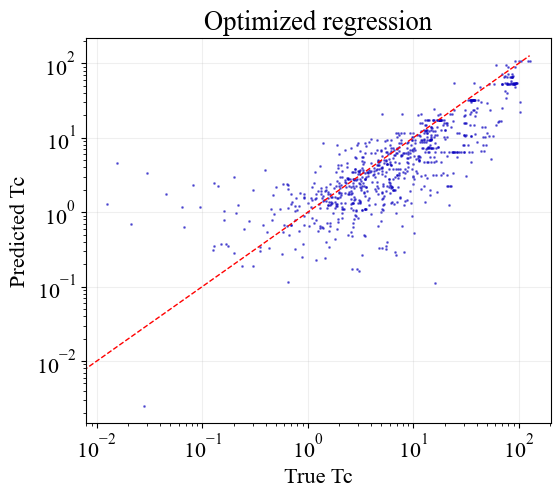

In [66]:
Yr_train_log = np.log1p(Yr_train)
Yr_test_log = np.log1p(Yr_test)

lgb_train = lgb.Dataset(Xr_train[feat_shap], Yr_train_log)
lgb_eval  = lgb.Dataset(Xr_test[feat_shap],  Yr_test_log, reference=lgb_train)

params = study_shap.best_params

patience = int(min(max(50, 0.1 / params['learning_rate']), 500))

# Train the model:
gbm = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=1000,               # How many rounds for training
                valid_sets=lgb_eval,                # Data to use for validation
                callbacks=[early_stopping(patience)])     # Stops if no improvement is seen in N=20 rounds.


y_pred = np.expm1(gbm.predict(Xr_test[feat_shap], num_iteration=gbm.best_iteration))

# Evaluate initial model:
y_pred_val = np.expm1(gbm.predict(Xr_val[feat_shap], num_iteration=gbm.best_iteration))
mse  = mean_squared_error(Yr_val, y_pred_val)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(Yr_val, y_pred_val)
r2   = r2_score(Yr_val, y_pred_val)

print('Regression performance on validation set')
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

fig, ax = plt.subplots(1, figsize=(6, 5), dpi=100)
ax.scatter(Yr_val, y_pred_val, s=1, alpha=0.5)
ax.plot([Yr_val.min(), Yr_val.max()], [Yr_val.min(), Yr_val.max()], 'r--', lw=1)
ax.set_xlabel('True Tc')
ax.set_ylabel('Predicted Tc')
ax.set_title(f'Initial LGB  |  R² = {r2:.3f}')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Optimized regression')

plt.show()
